In [1]:
print("Heart Disease Prediction Project Started")

Heart Disease Prediction Project Started


In [8]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [15]:
import pandas as pd

df = pd.read_csv("/content/heart.csv")

In [16]:
# Display First 10 Rows

df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [17]:
# Check Missing Values

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [18]:
# Data Types Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [19]:
# Summary Statistics

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


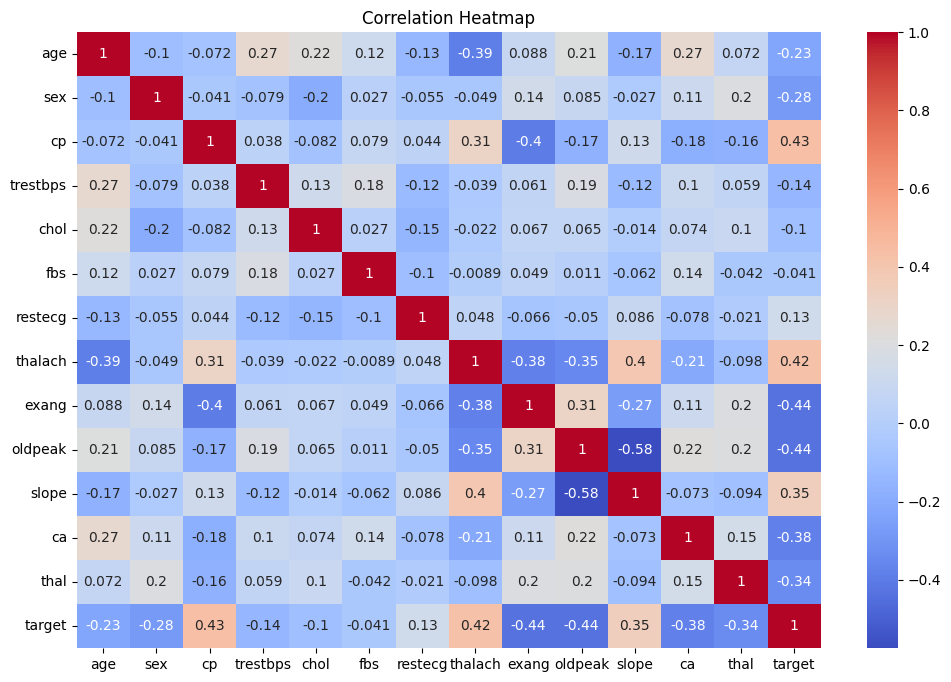

In [20]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

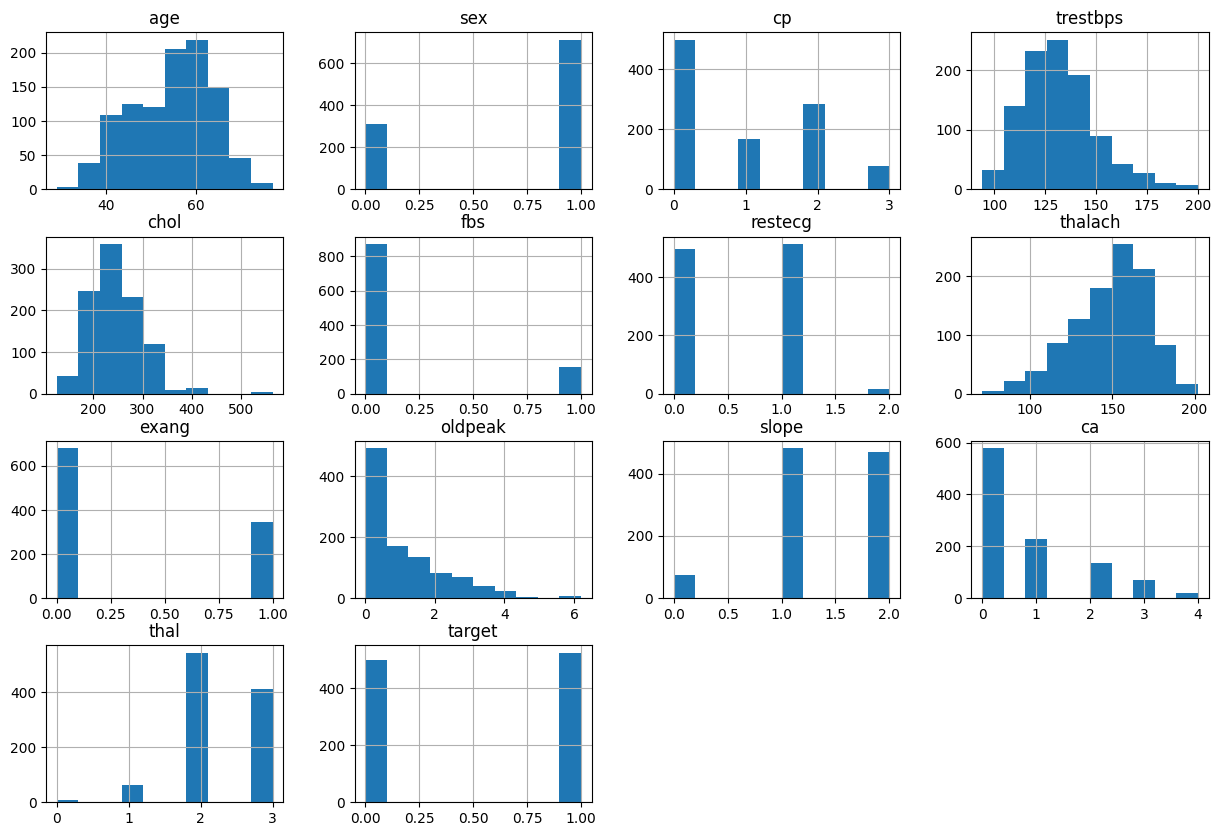

In [23]:
# Histogram

df.hist(figsize=(15,10))

plt.show()

## Observation

1. The correlation heatmap shows that some features have a strong relationship with the target variable.

2. Histograms indicate the distribution of numerical features.

3. Most features are normally distributed, while some are slightly skewed.

In [24]:
# Check Missing Values

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [25]:
# Remove Missing Values (if any)

df = df.dropna()

In [26]:
# Dataset Shape

df.shape

(1025, 14)

In [27]:
# Check Data Types

df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [28]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

In [29]:
# Separate Features and Target

X = df.drop("target", axis=1)

y = df["target"]

In [30]:
# Feature Scaling

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [31]:
# Feature Names

feature_names = df.drop("target", axis=1).columns

print(feature_names)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')


## Feature Selection

All input features were selected except the target column.
The target column is used as the output variable for prediction.

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
# Create Model

model = LogisticRegression()

In [36]:
# Train Model

model.fit(X_train, y_train)

LogisticRegression()

In [37]:
from sklearn.metrics import accuracy_score

In [38]:
# Predict Test Data

y_pred = model.predict(X_test)

In [39]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7951219512195122


In [40]:
print("Accuracy :", accuracy * 100,"%")

Accuracy : 79.51219512195122 %


In [41]:
# Actual vs Predicted Labels

result = pd.DataFrame({
    "Actual Label": y_test.values,
    "Predicted Label": y_pred
})

result.head(10)

,Actual Label,Predicted Label
0,1,1
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,1,1
9,0,0


## Final Observation

1. The Heart Disease Prediction model was successfully trained using Logistic Regression.
2. The model achieved good accuracy on the test dataset.
3. The model predicted heart disease status for 10 patients.
4. Logistic Regression is effective for this binary classification problem.